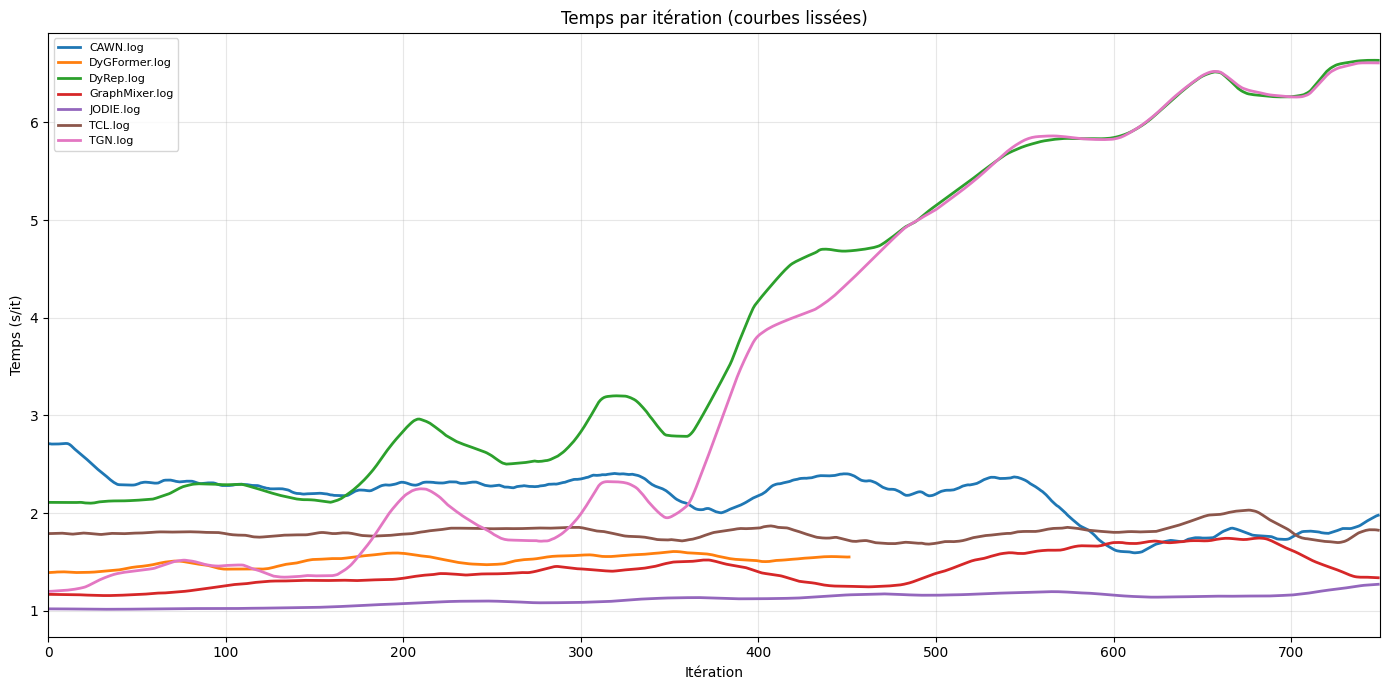

In [17]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter, uniform_filter1d

# Trouve tous les fichiers
files = sorted(glob.glob("./logs_1h/eval_reconstruction_CTD5G_CTD5G_fasttext_retrain_*"))

# Regex pour récupérer "2.93" dans "2.93s/it"
pattern = re.compile(r"([0-9]+(?:\.[0-9]+)?)s/it")

plt.figure(figsize=(14, 7))

for filename in files:
    values = []

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                values.append(float(m.group(1)))

    if len(values) == 0:
        continue

    # Coupe à 750 itérations
    values = np.array(values[:MAX_IT])

    # --- Lissage plus agressif ---
    # Suppression des pics locaux
    smooth = median_filter(values, size=31)

    # Lissage global
    smooth = uniform_filter1d(smooth, size=50)

    plt.plot(
        smooth,
        linewidth=2,
        label=os.path.basename(filename).replace(
            "eval_reconstruction_CTD5G_CTD5G_fasttext_retrain_", ""
        ),
    )

plt.xlabel("Itération")
plt.ylabel("Temps (s/it)")
plt.title("Temps par itération (courbes lissées)")
plt.xlim(0, MAX_IT)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()